# Applied Methods of Analysis II: Final Project
**Name:** Jonas Nepozitek  
**Date:** April 27, 2026

In [2]:
import pandas as pd
import wbgapi as wb
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from IPython.display import display, HTML

## Part III. Data Description

In [3]:
eu = [
    'AUT', 'BEL', 'BGR', 'CYP', 'CZE', 'DNK', 'EST', 'FIN',
    'FRA', 'DEU', 'GRC', 'HUN', 'IRL', 'ITA', 'LVA', 'LTU',
    'LUX', 'MLT', 'NLD', 'POL', 'PRT', 'ROU', 'SVK', 'SVN',
    'ESP', 'SWE', 'GBR',
]

eurozone = [
    'AUT', 'BEL', 'FIN', 'FRA', 'DEU', 'GRC', 'IRL', 'ITA',
    'LUX', 'NLD', 'PRT', 'SVN', 'ESP'
]

ALL_YEARS  = list(range(2004, 2014))
EVENT_YEAR = 2008
BASE_TAU   = -1   # 2007 = base year, omitted from regression

In [4]:
gdp_panel = wb.data.DataFrame('NY.GDP.PCAP.KD', time=range(2004, 2014))
gdp_panel = gdp_panel[gdp_panel.index.isin(eu)]

unemp_panel = wb.data.DataFrame('SL.UEM.TOTL.ZS', time=range(2004, 2014))
unemp_panel = unemp_panel[unemp_panel.index.isin(eu)]

manufacturing = wb.data.DataFrame('NV.IND.MANF.ZS', time=2007)
manufacturing = manufacturing[manufacturing.index.isin(eu)]
manufacturing = manufacturing.rename(columns={manufacturing.columns[0]: 'manufacturing'})

wgi = pd.read_excel('inputs/Raw Data from Underlying Data Sources (1996-2024).xlsx', sheet_name='GE')
wgi = (
    wgi[
        (wgi['indicator'] == 'average of all ge indicators')
        & (wgi['econ_code'].isin(eu))
        & (wgi['production_year'] == 2007)
    ]
    [['econ_code', 'production_year', 'value']]
    .groupby(['econ_code', 'production_year'])['value']
    .mean()
    .reset_index()
    .pivot(index='econ_code', columns='production_year', values='value')
)
wgi = wgi.rename(columns={wgi.columns[0]: 'wgi'})

In [5]:
def to_long(panel_df, value_name):
    df = panel_df.reset_index().rename(columns={panel_df.index.name or 'economy': 'country'})
    df = df.melt(id_vars='country', var_name='year', value_name=value_name)
    df['year'] = df['year'].str.replace('YR', '').astype(int)
    return df

gdp_long   = to_long(gdp_panel,   'gdp')
unemp_long = to_long(unemp_panel, 'unemp')

panel = gdp_long.merge(unemp_long, on=['country', 'year'])
panel['log_gdp']   = np.log(panel['gdp'])
panel['log_unemp'] = np.log(panel['unemp'])
panel['tau']       = (panel['year'] - EVENT_YEAR).astype(int)

covariates = pd.concat([manufacturing, wgi], axis=1).dropna()
covariates.index.name = 'country'
panel = panel.merge(covariates.reset_index(), on='country', how='inner')

med_manuf = covariates['manufacturing'].median()
med_wgi   = covariates['wgi'].median()
panel['high_manuf'] = (panel['manufacturing'] >= med_manuf).astype(int)
panel['high_wgi']   = (panel['wgi']           >= med_wgi).astype(int)
panel['eurozone']   = panel['country'].isin(eurozone).astype(int)

panel = panel.dropna(subset=['log_gdp', 'log_unemp']).sort_values(['country', 'year'])
print('Panel shape:', panel.shape)
print('Countries:', panel['country'].nunique())
print('Median manufacturing share:', med_manuf)
print('Median governance index:', med_wgi)
panel.head()

Panel shape: (260, 12)
Countries: 26
Median manufacturing share: 15.50358821134045
Median governance index: 0.724125735


,country,year,gdp,unemp,log_gdp,log_unemp,tau,manufacturing,wgi,high_manuf,high_wgi,eurozone
0,AUT,2004,40333.330718,5.969,10.604933,1.786579,-4,18.548721,0.856818,1,1,1
26,AUT,2005,40989.013178,5.682,10.621059,1.737303,-3,18.548721,0.856818,1,1,1
52,AUT,2006,42120.155700,5.320,10.648282,1.671473,-2,18.548721,0.856818,1,1,1
78,AUT,2007,43568.830224,4.909,10.682097,1.591070,-1,18.548721,0.856818,1,1,1
104,AUT,2008,44063.864202,4.198,10.693395,1.434608,0,18.548721,0.856818,1,1,1


### Country-level crisis effects

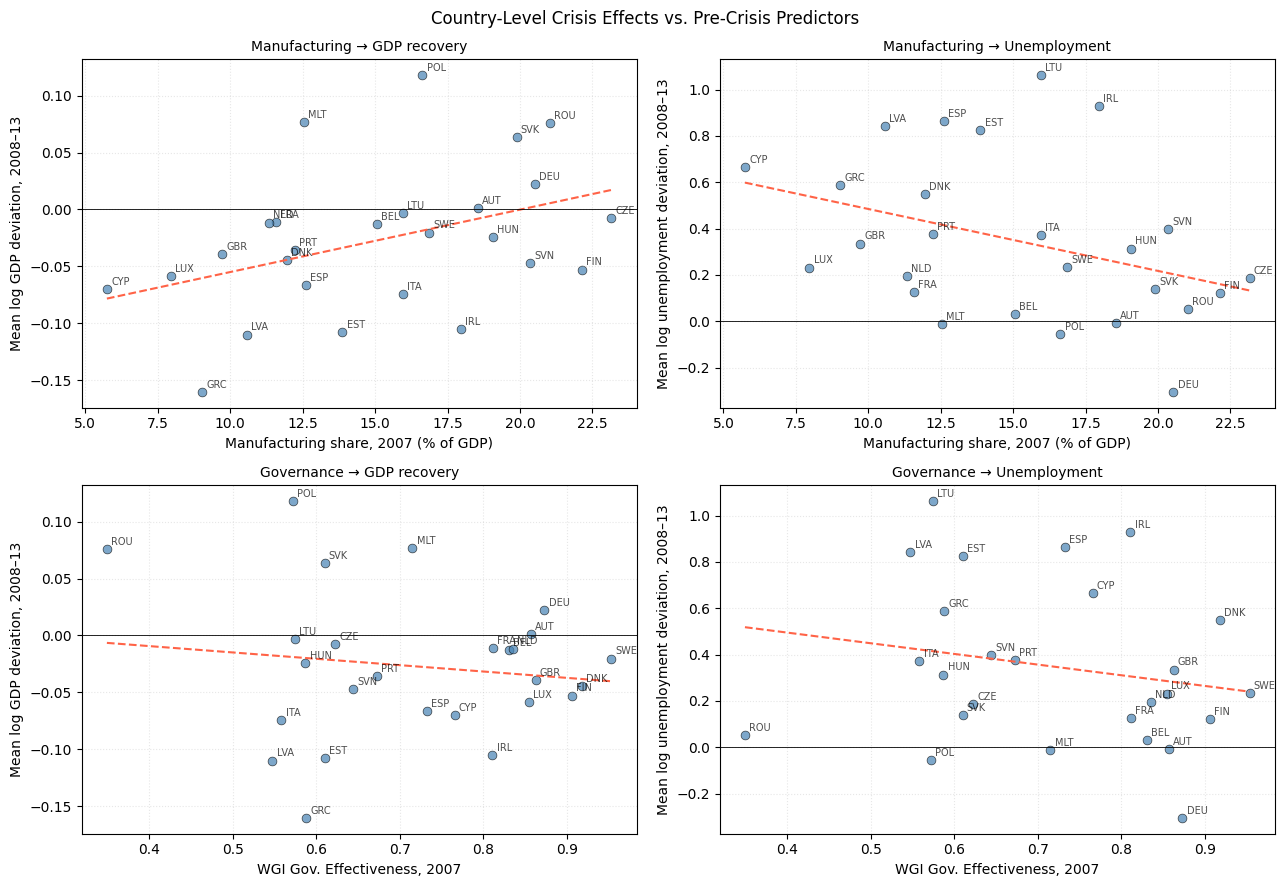

In [6]:
def country_post_event_effect(panel_df, outcome, base_tau=BASE_TAU):
    """For each country: mean(post-event log Y) − base-year log Y."""
    base_year = EVENT_YEAR + base_tau
    rows = []
    for c, sub in panel_df.groupby('country'):
        sub = sub.sort_values('year')
        if base_year not in sub['year'].values:
            continue
        base_val = sub.loc[sub['year'] == base_year, outcome].iloc[0]
        post     = sub.loc[sub['tau'] >= 0, outcome] - base_val
        rows.append({'country': c, 'effect': post.mean()})
    return pd.DataFrame(rows)


country_gdp   = country_post_event_effect(panel, 'log_gdp')
country_unemp = country_post_event_effect(panel, 'log_unemp')
country_summary = (
    country_gdp.rename(columns={'effect': 'gdp_post'})
    .merge(country_unemp.rename(columns={'effect': 'unemp_post'}), on='country')
    .merge(covariates.reset_index(), on='country')
)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
scatter_pairs = [
    (axes[0, 0], 'manufacturing', 'gdp_post',
     'Manufacturing share, 2007 (% of GDP)',
     'Mean log GDP deviation, 2008–13',
     'Manufacturing → GDP recovery'),
    (axes[0, 1], 'manufacturing', 'unemp_post',
     'Manufacturing share, 2007 (% of GDP)',
     'Mean log unemployment deviation, 2008–13',
     'Manufacturing → Unemployment'),
    (axes[1, 0], 'wgi', 'gdp_post',
     'WGI Gov. Effectiveness, 2007',
     'Mean log GDP deviation, 2008–13',
     'Governance → GDP recovery'),
    (axes[1, 1], 'wgi', 'unemp_post',
     'WGI Gov. Effectiveness, 2007',
     'Mean log unemployment deviation, 2008–13',
     'Governance → Unemployment'),
]

for ax, x_var, y_var, xlabel, ylabel, title in scatter_pairs:
    ax.scatter(country_summary[x_var], country_summary[y_var],
               s=40, color='steelblue', alpha=0.7, edgecolor='black', linewidth=0.5)
    for _, row in country_summary.iterrows():
        ax.annotate(row['country'], (row[x_var], row[y_var]),
                    fontsize=7, alpha=0.7, xytext=(3, 3), textcoords='offset points')
    x = country_summary[x_var]; y = country_summary[y_var]
    coef = np.polyfit(x, y, 1)
    xs = np.linspace(x.min(), x.max(), 50)
    ax.plot(xs, np.polyval(coef, xs), color='tomato', linewidth=1.5, linestyle='--')
    ax.axhline(0, color='black', linewidth=0.6)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=10)
    ax.grid(axis='both', linestyle=':', alpha=0.3)

plt.suptitle('Country-Level Crisis Effects vs. Pre-Crisis Predictors', fontsize=12)
plt.tight_layout()
plt.savefig('outputs/country_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

## Part IV. Methodology

### Event study specification
Per Kleven, Landais & Leite-Mariante (2024, eq. 1), for each group *g* (e.g. high-manufacturing or low-manufacturing), we estimate separately:
$$\log Y^{g}_{i,t} = \alpha^g_i + \sum_{\tau \neq -1} \beta^g_\tau \cdot \mathbf{1}[t - 2008 = \tau] + \varepsilon^g_{i,t}$$
where $\alpha^g_i$ are country fixed effects and the $\beta^g_\tau$ trace the average
log-deviation of the outcome at event time τ from its 2007 (τ = −1) base level.
Standard errors are clustered at the country level.

### Crisis penalty
Following the child-penalty definition (Kleven et al., eq. 3):
$$\text{Crisis Penalty}^X \equiv \mathbb{E}\!\left[\beta^{\text{Low-}X}_\tau - \beta^{\text{High-}X}_\tau \mid \tau \geq 0\right] - \mathbb{E}\!\left[\beta^{\text{Low-}X}_\tau - \beta^{\text{High-}X}_\tau \mid \tau < -1\right]$$
For GDP, a *negative* crisis penalty means the low-X group lost more output than the
high-X group; for unemployment, a *positive* crisis penalty means the low-X group's
unemployment rose more.

### Identification note
Unlike Kleven et al., where event time and calendar time are separately identified
because individuals experience first child birth in different years, here the event
occurs simultaneously in 2008 for all countries. Year and event-time dummies are
therefore collinear, and only one set is included. Identification rests on the
assumption of parallel pre-trends across the high- and low-X groups, which is testable
visually in the event-study plots.

In [7]:
def _tau_col(t):
    """Safe dummy column name for an integer event time t."""
    return f"tau_m{abs(t)}" if t < 0 else f"tau_p{t}"


def estimate_event_study(df, outcome, base_tau=BASE_TAU):
    """
    OLS event study for one country group:
        outcome ~ country FE + Σ β_τ · 1[t - 2008 = τ]   (τ ≠ base_tau)
    Country-clustered SEs. Returns coefficient table and the fitted model.
    """
    df = df.copy()
    taus_nonbase = sorted([int(t) for t in df['tau'].unique() if int(t) != base_tau])

    # Manual event-time dummies (avoids patsy naming issues)
    tau_cols = []
    for t in taus_nonbase:
        col = _tau_col(t)
        df[col] = (df['tau'] == t).astype(int)
        tau_cols.append(col)

    rhs     = ' + '.join(tau_cols)
    formula = f"{outcome} ~ C(country) + {rhs}"
    model   = smf.ols(formula, data=df).fit(
        cov_type='cluster', cov_kwds={'groups': df['country']}
    )

    rows = [{'tau': base_tau, 'beta': 0.0, 'se': 0.0, 'ci_low': 0.0, 'ci_high': 0.0}]
    for t in taus_nonbase:
        col = _tau_col(t)
        if col not in model.params.index:
            continue
        b, s = float(model.params[col]), float(model.bse[col])
        rows.append({
            'tau': t, 'beta': b, 'se': s,
            'ci_low': b - 1.96 * s, 'ci_high': b + 1.96 * s,
        })
    return pd.DataFrame(rows).sort_values('tau').reset_index(drop=True), model


# Estimate all eight event studies (2 splits × 2 groups × 2 outcomes)
results = {}
for split_var, split_label in [('high_manuf', 'Manufacturing'), ('high_wgi', 'Governance')]:
    for outcome in ['log_gdp', 'log_unemp']:
        for grp_val, grp_label in [(1, 'High'), (0, 'Low')]:
            sub = panel[panel[split_var] == grp_val]
            res, _ = estimate_event_study(sub, outcome)
            results[(split_label, outcome, grp_label)] = res

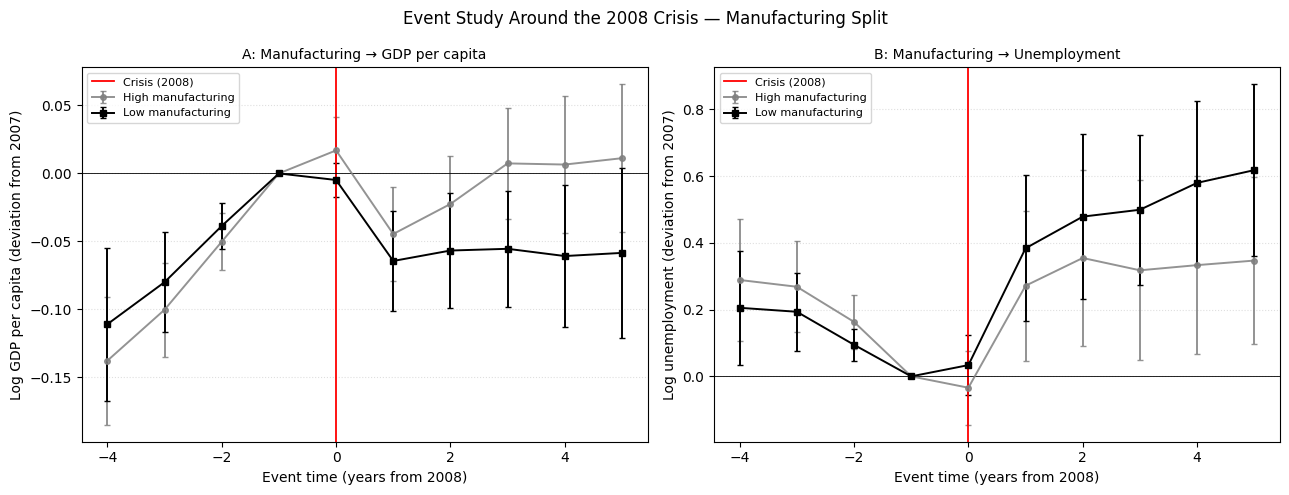

In [8]:
def plot_event_pair(ax, df_high, df_low, label_high, label_low,
                    ylabel, title, ymin=None, ymax=None):
    """Kleven-style two-line event study plot with 95% CI bars."""
    ax.errorbar(df_high['tau'], df_high['beta'],
                yerr=1.96 * df_high['se'],
                fmt='o-', color='gray', alpha=0.85, capsize=2.5,
                markersize=4, linewidth=1.4, label=label_high)
    ax.errorbar(df_low['tau'], df_low['beta'],
                yerr=1.96 * df_low['se'],
                fmt='s-', color='black', capsize=2.5,
                markersize=4, linewidth=1.4, label=label_low)

    ax.axvline(0, color='red', linewidth=1.3, label='Crisis (2008)')
    ax.axhline(0, color='black', linewidth=0.6)
    ax.set_xlabel('Event time (years from 2008)')
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=10)
    if ymin is not None and ymax is not None:
        ax.set_ylim(ymin, ymax)
    ax.legend(fontsize=8, loc='best')
    ax.grid(axis='y', linestyle=':', alpha=0.4)


fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_event_pair(
    axes[0],
    results[('Manufacturing', 'log_gdp', 'High')],
    results[('Manufacturing', 'log_gdp', 'Low')],
    'High manufacturing', 'Low manufacturing',
    'Log GDP per capita (deviation from 2007)',
    'A: Manufacturing → GDP per capita',
)
plot_event_pair(
    axes[1],
    results[('Manufacturing', 'log_unemp', 'High')],
    results[('Manufacturing', 'log_unemp', 'Low')],
    'High manufacturing', 'Low manufacturing',
    'Log unemployment (deviation from 2007)',
    'B: Manufacturing → Unemployment',
)
plt.suptitle('Event Study Around the 2008 Crisis — Manufacturing Split', fontsize=12)
plt.tight_layout()
plt.savefig('outputs/event_study_manufacturing.png', dpi=300, bbox_inches='tight')
plt.show()

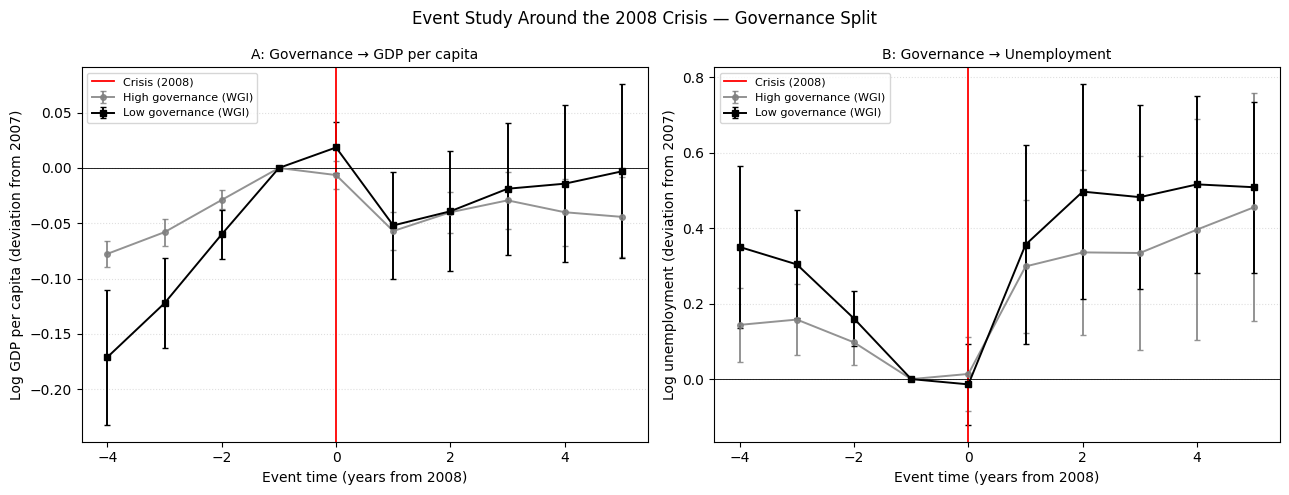

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_event_pair(
    axes[0],
    results[('Governance', 'log_gdp', 'High')],
    results[('Governance', 'log_gdp', 'Low')],
    'High governance (WGI)', 'Low governance (WGI)',
    'Log GDP per capita (deviation from 2007)',
    'A: Governance → GDP per capita',
)
plot_event_pair(
    axes[1],
    results[('Governance', 'log_unemp', 'High')],
    results[('Governance', 'log_unemp', 'Low')],
    'High governance (WGI)', 'Low governance (WGI)',
    'Log unemployment (deviation from 2007)',
    'B: Governance → Unemployment',
)
plt.suptitle('Event Study Around the 2008 Crisis — Governance Split', fontsize=12)
plt.tight_layout()
plt.savefig('outputs/event_study_governance.png', dpi=300, bbox_inches='tight')
plt.show()

## Part V. Crisis Penalties

The crisis penalty is the differential post-event response of the low-X group
relative to the high-X group, net of any pre-event difference. Estimates and
clustered standard errors come from a single pooled regression that interacts
the high-group dummy with each event-time dummy:
$$\log Y_{i,t} = \alpha_i + \sum_{\tau \neq -1} \left[\beta_\tau \mathbf{1}[t-2008=\tau] + \delta_\tau \cdot \text{HighGroup}_i \cdot \mathbf{1}[t-2008=\tau]\right] + \varepsilon_{i,t}$$
The crisis penalty is then $\bar{\delta}_{pre} - \bar{\delta}_{post}$, computed via a
linear contrast on the fitted model so that the standard error accounts for
country-level clustering in $\hat{\delta}_\tau$.

In [10]:
def crisis_penalty(df, outcome, group_var, base_tau=BASE_TAU):
    """
    Pooled DiD with high-group × event-time interactions.
    Returns: deltas dataframe, penalty estimate, penalty SE, fitted model.

    Uses manual dummy construction so variable names are predictable
    (avoids patsy's interaction naming conventions).
    """
    df = df.copy()
    df['high'] = df[group_var].astype(int)
    taus_nonbase = sorted([int(t) for t in df['tau'].unique() if int(t) != base_tau])

    # Build main effect and interaction dummies manually
    main_cols, int_cols = [], []
    for t in taus_nonbase:
        m_col = _tau_col(t)
        i_col = m_col + '_x_high'
        df[m_col] = (df['tau'] == t).astype(int)
        df[i_col] = df[m_col] * df['high']
        main_cols.append(m_col)
        int_cols.append(i_col)

    rhs     = ' + '.join(main_cols + int_cols)
    formula = f"{outcome} ~ C(country) + {rhs}"
    model   = smf.ols(formula, data=df).fit(
        cov_type='cluster', cov_kwds={'groups': df['country']}
    )

    delta_rows = []
    for t, i_col in zip(taus_nonbase, int_cols):
        if i_col not in model.params.index:
            continue
        delta_rows.append({
            'tau':      t,
            'delta':    float(model.params[i_col]),
            'se':       float(model.bse[i_col]),
            'var_name': i_col,
        })
    deltas = pd.DataFrame(delta_rows)

    if deltas.empty:
        return deltas, np.nan, np.nan, model

    pre_vars  = deltas.loc[deltas['tau'] < base_tau, 'var_name'].tolist()
    post_vars = deltas.loc[deltas['tau'] >= 0,        'var_name'].tolist()

    if not pre_vars or not post_vars:
        return deltas, np.nan, np.nan, model

    # Linear contrast: (1/|pre|) Σ_pre δ_τ − (1/|post|) Σ_post δ_τ
    contrast = pd.Series(0.0, index=model.params.index)
    for v in pre_vars:  contrast[v] += 1.0 / len(pre_vars)
    for v in post_vars: contrast[v] -= 1.0 / len(post_vars)

    test = model.t_test(contrast.values)
    return deltas, float(test.effect[0]), float(test.sd[0]), model


penalty_rows = []
for split_var, split_label in [('high_manuf', 'Manufacturing'), ('high_wgi', 'Governance')]:
    for outcome, outcome_label in [('log_gdp', 'GDP per capita'), ('log_unemp', 'Unemployment')]:
        deltas, pen, pen_se, _ = crisis_penalty(panel, outcome, split_var)
        penalty_rows.append({
            'Predictor':       split_label,
            'Outcome':         outcome_label,
            'Crisis penalty':  round(pen, 4)    if pd.notna(pen)    else np.nan,
            'SE':              round(pen_se, 4) if pd.notna(pen_se) else np.nan,
            't-stat':          round(pen / pen_se, 3) if (pd.notna(pen_se) and pen_se > 0) else np.nan,
        })

penalty_table = pd.DataFrame(penalty_rows)
print('=== Crisis Penalties (2008–2013, base τ = -1) ===\n')
print('Sign convention: penalty = avg(δ_pre) − avg(δ_post) where δ_τ is the high-group')
print('coefficient at event time τ. For GDP: positive penalty ⇒ high-X group fared')
print('better. For unemployment: positive penalty ⇒ high-X group saw smaller increase.\n')
display(penalty_table)

=== Crisis Penalties (2008–2013, base τ = -1) ===

Sign convention: penalty = avg(δ_pre) − avg(δ_post) where δ_τ is the high-group
coefficient at event time τ. For GDP: positive penalty ⇒ high-X group fared
better. For unemployment: positive penalty ⇒ high-X group saw smaller increase.



C:\Users\nepoz\AppData\Local\Temp\ipykernel_5460\4048650893.py:56: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return deltas, float(test.effect[0]), float(test.sd[0]), model
C:\Users\nepoz\AppData\Local\Temp\ipykernel_5460\4048650893.py:56: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return deltas, float(test.effect[0]), float(test.sd[0]), model
C:\Users\nepoz\AppData\Local\Temp\ipykernel_5460\4048650893.py:56: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  retu

,Predictor,Outcome,Crisis penalty,SE,t-stat
0,Manufacturing,GDP per capita,-0.0655,0.0364,-1.799
1,Manufacturing,Unemployment,0.2428,0.1505,1.613
2,Governance,GDP per capita,0.0809,0.0349,2.320
3,Governance,Unemployment,-0.0533,0.1592,-0.335


In [12]:
print("Manufacturing × Unemployment, terminal (τ=5) coefficients:")
print(f"  High group: β = {results[('Manufacturing','log_unemp','High')].iloc[-1]['beta']:+.4f}")
print(f"  Low group:  β = {results[('Manufacturing','log_unemp','Low')].iloc[-1]['beta']:+.4f}")
print(f"  Difference: {results[('Manufacturing','log_unemp','Low')].iloc[-1]['beta'] - results[('Manufacturing','log_unemp','High')].iloc[-1]['beta']:+.4f}")
print("---")
print("Governance × GDP, τ=-4 coefficients:")
print(f"  High group: {results[('Governance','log_gdp','High')].iloc[0]['beta']:+.4f}")
print(f"  Low group:  {results[('Governance','log_gdp','Low')].iloc[0]['beta']:+.4f}")

Manufacturing × Unemployment, terminal (τ=5) coefficients:
  High group: β = +0.3470
  Low group:  β = +0.6180
  Difference: +0.2710
---
Governance × GDP, τ=-4 coefficients:
  High group: -0.0776
  Low group:  -0.1709
